# Crumblr — Compositional Differential Abundance

Uses **crumblr** (CLR + dream mixed-effects) as an alternative to scCODA.  
Same dataset, same tissue × annotation-level grid.

**Setup (one-time):** `bash /home/gdallagl/myworkdir/XDP/data/crumblr/crumblr/setup_env.sh`  
**Kernel:** any env with `scanpy` + `pandas` (e.g. `python3`/`.venv`) — crumblr runs in its own venv via subprocess.

In [10]:
%load_ext autoreload
%autoreload 2

import os, subprocess, json, glob
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from IPython.display import display, Image
import numpy as np
import seaborn as sns

from utils import preprocessing

# ── Paths ─────────────────────────────────────────────────────────────────────
TISSUE = "Striatum" # "Striatum" / "SN" / "DFC"
if TISSUE == "Striatum":
    ADATA          = f"/home/gdallagl/myworkdir/XDP/data/XDP/NucSec/adatas/{TISSUE}/{TISSUE}_combined_QC_mmc_ct-cured_zoned.h5ad"
elif (TISSUE == "SN") | (TISSUE == "DFC"):
    ADATA          = f"/home/gdallagl/myworkdir/XDP/data/XDP/NucSec/adatas/{TISSUE}/{TISSUE}_combined_QC_mmc_ct-cured.h5ad"

TISSUE         =  ADATA.split("/")[-2]
SAVE_FOLDER    = f"/home/gdallagl/myworkdir/XDP/data/XDP/NucSec/compositional/crumblr/{TISSUE}"
CRUMBLR_SCRIPT = "/home/gdallagl/myworkdir/XDP/data/crumblr/crumblr/run_workflow.py"
MAPPING_JSON   = "/home/gdallagl/myworkdir/XDP/utils/STR_cell_types_annotation/group_level_mmc_mapping.json"

# ── Study design ──────────────────────────────────────────────────────────────
SAMPLE_COL     = "donor_id"
CONTRAST_COL   = "condition"
CONTRAST_REF   = "Control"
CONTRAST_STIM  = "XDP"
FIXED_EFFECTS  = ["sex", "cohort", "age_of_death"]  # fixed covariates
RANDOM_EFFECTS = []  # donor_id can't be a random effect: 1 sample per donor after aggregation → use lmFit

os.makedirs(SAVE_FOLDER, exist_ok=True)

print(TISSUE)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Striatum


In [11]:
adata = sc.read_h5ad(ADATA, backed="r")
print(adata)
print("Cell counts by tissue:", adata.obs["tissue"].value_counts().to_dict())

AnnData object with n_obs × n_vars = 231080 × 38601 backed at '/home/gdallagl/myworkdir/XDP/data/XDP/NucSec/adatas/Striatum/Striatum_combined_QC_mmc_ct-cured_zoned.h5ad'
    obs: 'background_fraction', 'cell_probability', 'cell_size', 'droplet_efficiency', 'barcode', 'bcl', 'rna_index', 'library', 'library__barcode', 'frac_mito', 'mol_info_nUMI', 'mol_info_nRead', 'frac_intronic', 'donor_id', 'vireo_prob_max', 'vireo_prob_doublet', 'vireo_n_vars', 'vireo_best_singlet', 'vireo_best_doublet', 'vireo_doublet_logLikRatio', 'dropsift_frac_contamination', 'dropsift_training_label_is_cell', 'dropsift_empty_gene_module_score', 'dropsift_is_cell', 'dropsift_is_cell_prob', 'cell_class', 'leiden_0.1', 'leiden_0.2', 'leiden_0.3', 'leiden_0.4', 'leiden_0.5', 'tissue', 'broad_original_cell_type', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes

In [12]:
# Remove bad cell types 
adata = adata[~adata.obs["ct_for_deg"].isin(["-Low_quality"])].to_memory().copy()

# Remove cell types wiht too few samples
cell_type_counts = adata.obs["ct_for_deg"].value_counts()
cell_types_to_keep = cell_type_counts[cell_type_counts >= 10].index
adata = adata[adata.obs["ct_for_deg"].isin(cell_types_to_keep)].copy()

In [ ]:
# # ATTENTIO: oly for now:
# adata.obs["ct_for_deg"].replace({"Matrix_D1": "Matrix", "Matrix_D2": "Matrix", "Patch_D1": "Patch", "Patch_D2": "Patch"}, inplace=True)
# adata.obs["ct_for_deg"].value_counts()

/tmp/ipykernel_2172399/1385089709.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  adata.obs["ct_for_deg"].replace({"Matrix_D1": "Matrix", "Matrix_D2": "Matrix", "Patch_D1": "Patch", "Patch_D2": "Patch"}, inplace=True)
/tmp/ipykernel_2172399/1385089709.py:2: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  adata.obs

ct_for_deg
Oligodendrocyte      122867
Astrocyte             27715
Matrix                22782
Microglia              9868
non-MSN                8335
Patch                  7269
OPC                    7219
eMSN_D1D2              2830
Ependymal              1451
eMSN_NUDAP             1359
-TAFA1                 1005
eMSN_StrioMat           885
Macrophages             761
Endothelial_BBB         711
COP                     440
Lymphocyte              415
Pericytes               334
Fibroblasts             230
SmoothMuscleCells        88
Monocytes                81
Name: count, dtype: int64

## Helper functions

In [13]:
import sys
sys.path.insert(0, "/home/gdallagl/myworkdir/XDP/data/crumblr")  # directory, not file path
from plot_crumblr import plot_all as _plot_all

# Columns that every CSV needs (cell-type col is added separately per run)
META_COLS = [SAMPLE_COL, CONTRAST_COL, *FIXED_EFFECTS]

# Subprocess env: override the Jupyter inline backend (invalid outside Jupyter)
_SUBPROCESS_ENV = {**os.environ, "MPLBACKEND": "Agg"}


def drop_bad_samples(adata):
    """Remove donors with any missing covariate."""
    bad = {s for col in META_COLS
              for s in adata.obs[adata.obs[col].isna()][SAMPLE_COL].unique()}
    return adata[~adata.obs[SAMPLE_COL].isin(bad)]

def filter_rare_celltypes(adata, ct_col, min_samples=5, min_cells_per_sample=3):
    """Remove cell types present in too few donors (would break lmFit)."""
    counts = (
        adata.obs[[ct_col, SAMPLE_COL]]
        .groupby([ct_col, SAMPLE_COL])
        .size()
        .reset_index(name="n_cells")
    )
    donor_counts = (
        counts[counts["n_cells"] >= min_cells_per_sample]
        .groupby(ct_col)[SAMPLE_COL]
        .nunique()
    )
    keep = donor_counts[donor_counts >= min_samples].index
    removed = set(adata.obs[ct_col].unique()) - set(keep)
    if removed:
        print(f"  removing {len(removed)} rare type(s): {sorted(removed)}")
    return adata[adata.obs[ct_col].isin(keep)]

def run_crumblr(adata_sub, ct_col, output_dir, label="", show=False):
    """
    Exports CSV → calls run_workflow.py → calls plot_crumblr.py → returns results

    Export a cell-level CSV, call run_workflow.py, then plot results with plot_crumblr.py.
    All CSVs + original PDFs/PNGs are saved to output_dir by run_workflow.py.
    Custom plots saved to output_dir/images/ by plot_crumblr.py.
    Returns the results DataFrame (one row per cell type × coefficient).
    """
    os.makedirs(output_dir, exist_ok=True)
    csv_path = os.path.join(output_dir, "cells.csv")

    # Write cell-level CSV (one row per cell, columns = ct + metadata)
    df = adata_sub.obs[[ct_col, *META_COLS]].dropna().copy()
    df[ct_col] = df[ct_col].astype(str)
    df.to_csv(csv_path, index=False)

    cmd = [
        "python", CRUMBLR_SCRIPT,
        "--csv",            csv_path,
        "--proportion-col", ct_col,
        "--sample-col",     SAMPLE_COL,   # one sample per donor → same as donor-col
        "--donor-col",      SAMPLE_COL,
        "--contrast",       CONTRAST_COL,
        "--ref-level",      CONTRAST_REF,
        "--output-dir",     output_dir,
        "--fixed-effects",  *FIXED_EFFECTS,
        "--random-effects", *RANDOM_EFFECTS,
        "--min-n-cells",    "30" # ATTENTION; ilter donors wiht less than 100 cells of the given type, otherwise lmFit will break → use filter_rare_celltypes() to remove rare types beforehand

    ]
    result = subprocess.run(cmd, capture_output=True, text=True, env=_SUBPROCESS_ENV)
    print(result.stdout[-2000:])  # trim output to avoid flooding the notebook
    if result.returncode != 0:
        print("STDERR:", result.stderr[-2000:])
        raise RuntimeError(f"crumblr failed → {output_dir}")

    # Custom plots: use actual cell type names, no internal class mapping
    _plot_all(output_dir, contrast_col=CONTRAST_COL, contrast_stim=CONTRAST_STIM, label=label, show=show)

    return pd.read_csv(os.path.join(output_dir, "crumblr_results.csv"))


def run_crumblr_grid(adata, annotation_levels, out_dir, show=False):
    """Run crumblr for every annotation level on the tissue adata."""

    # remove samples with nan in some metadata
    adata = drop_bad_samples(adata).to_memory().copy()

    df_list = []
    for ct_col in annotation_levels:
        
        label = f"{TISSUE} | {ct_col}"
        print(f"\n{'='*60}\n{label}")
        #print(adata.obs[ct_col].value_counts())

        # remove ct with too few cells or samples
        adata_ct = filter_rare_celltypes(adata, ct_col, min_samples=5, min_cells_per_sample=3)

        ct_out_dir = f"{out_dir}/{ct_col}"
        df = run_crumblr(adata_ct, ct_col, ct_out_dir, label=label, show=show)
        df["tissue"]     = TISSUE
        df["annotation"] = ct_col
        df_list.append(df)

    merged = pd.concat(df_list, ignore_index=True)
    merged.to_csv(f"{out_dir}/merged_results.csv", index=False)
    return merged

## All cells

using all cells, for each annotation granularity level.

### *) create cols for zones in striatum

Right now we have one col with zone share acvross all cell types, we need a single col per ct.

In [14]:
ZONE_CT_MAP = {
    "Matrix_D1": "zone", # just zone for zone_6
    "Matrix_D2": "zone",

    "Patch_D1":  "zone_4",
    "Patch_D2":  "zone_4",
    "eMSN_D1D2": "zone_4",
    "Astrocyte": "zone_4",
}


zone_by_Matrix_D1


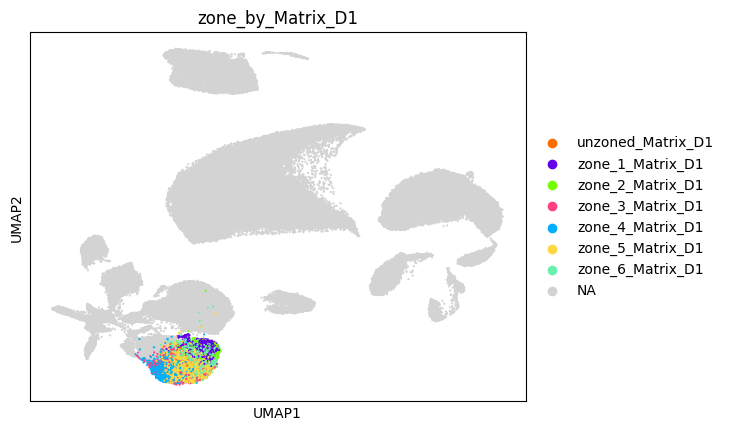


zone_by_Matrix_D2


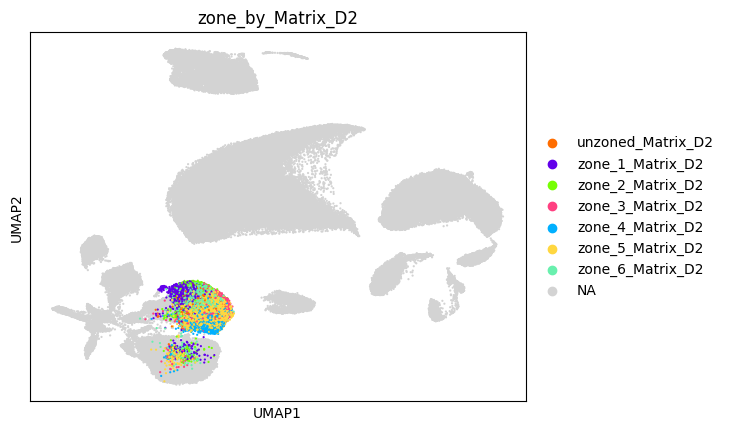


zone_4_by_Patch_D1


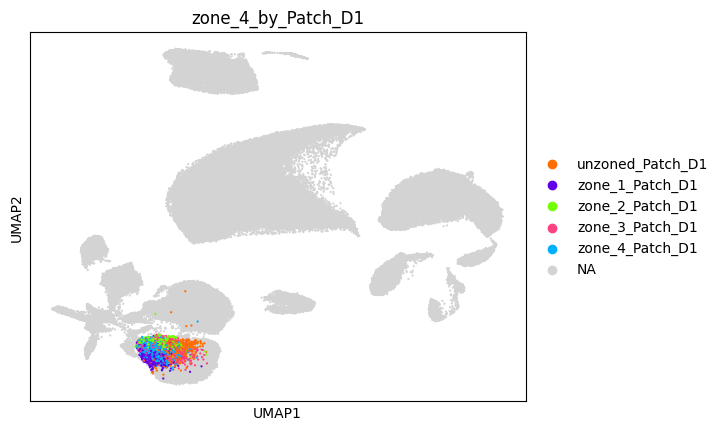


zone_4_by_Patch_D2


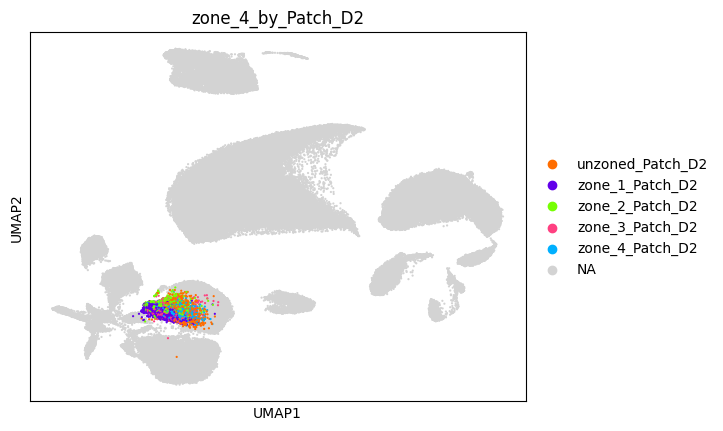


zone_4_by_eMSN_D1D2


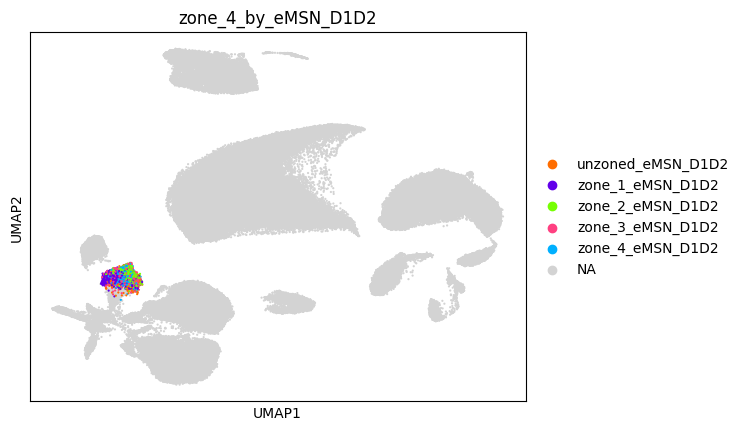


zone_4_by_Astrocyte


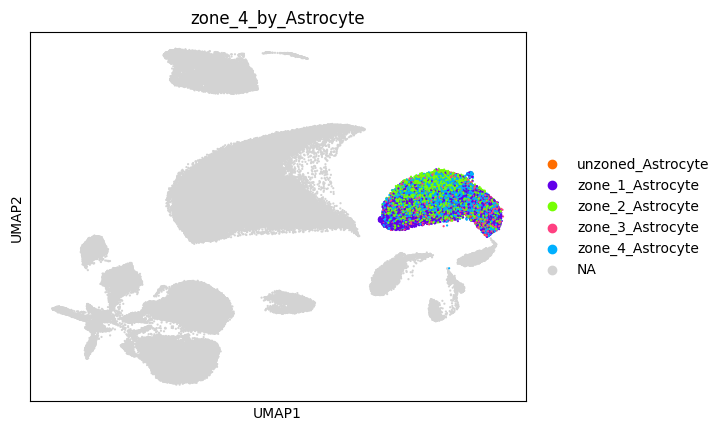

In [16]:
if TISSUE == "Striatum":
    col_zoning = []   # will collect the names of all new columns created

    for zone_ct, zone_variable in ZONE_CT_MAP.items():

        if zone_variable not in adata.obs.columns:
            print(f"WARNING: {zone_variable} not in adata, skipping {zone_ct}")
            continue

        zone_col = f"{zone_variable}_by_{zone_ct}"
        mask = adata.obs["ct_for_deg"] == zone_ct

        # Default: every cell keeps its ct_for_deg label
        adata.obs[zone_col] = adata.obs["ct_for_deg"].astype(str)

        # Create new column
        # Cells with a zone → "zone_<N>_<CT>"
        valid_mask = mask & adata.obs[zone_variable].notna() # are this cell type AND have a zone assignment (not Na)
        adata.obs.loc[valid_mask, zone_col] = (
            "zone_" + adata.obs.loc[valid_mask, zone_variable].astype(str)
            + "_" + zone_ct
        ) # five values to new col:  eg "zone_1_Matrix_D1" or just "orign ct type"

        # Save the zone name sof his col for plotting
        zones_names = adata.obs.loc[valid_mask, zone_col].unique().tolist()

        # Cells in this CT but without zone assignment 
        unzoned_label = "unzoned_" + zone_ct
        adata.obs.loc[mask & adata.obs[zone_variable].isna(), zone_col] = unzoned_label

        print(f"\n{zone_col}")
        #print(adata.obs[zone_col].value_counts())
        col_zoning.append(zone_col)

        sc.pl.umap(adata, color=zone_col,
                   groups=[*zones_names, zone_ct, unzoned_label],
                   size=10, title=zone_col, palette=preprocessing.custom_palette)


In [17]:
LEVELS_ALL = ["ct_for_deg"]

if TISSUE == "Striatum":
    LEVELS_ALL = LEVELS_ALL + col_zoning # Only Striatum has zones
    LEVELS_ALL = LEVELS_ALL + ["Class_name", "Subclass_name", "Group_name"] # only stritum has atals for all ct

print("Annotation levels:", LEVELS_ALL)

df_all = run_crumblr_grid(adata, annotation_levels=LEVELS_ALL, out_dir = f"{SAVE_FOLDER}/all_cells", show=False)
df_all.head()

Annotation levels: ['ct_for_deg', 'zone_by_Matrix_D1', 'zone_by_Matrix_D2', 'zone_4_by_Patch_D1', 'zone_4_by_Patch_D2', 'zone_4_by_eMSN_D1D2', 'zone_4_by_Astrocyte', 'Class_name', 'Subclass_name', 'Group_name']

Striatum | ct_for_deg


/tmp/ipykernel_720848/606176857.py:22: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby([ct_col, SAMPLE_COL])
/tmp/ipykernel_720848/606176857.py:28: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(ct_col)[SAMPLE_COL]


[1/6] Loading /home/gdallagl/myworkdir/XDP/data/XDP/NucSec/compositional/crumblr/Striatum/all_cells/ct_for_deg/cells.csv …
[2/6] Aggregating cell counts …
  Contrast 'condition' detected as categorical.
  Samples: 47  |  Cell types: 20
[3/6] Formula: ~ condition + sex + cohort + age_of_death
[4/6] Running crumblr (R) …

[R] /home/gdallagl/myworkdir/XDP/data/crumblr/micromamba_root/envs/crumblr/bin/Rscript … formula='~ condition + sex + cohort + age_of_death'
── Loading data ────────────────────────────────────────────────────────
  Samples: 47  |  Cell types: 20
  Formula: ~ condition + sex + cohort + age_of_death
  Contrast variable: condition
── Running crumblr ─────────────────────────────────────────────────────
── Fitting dream model ─────────────────────────────────────────────────
── Extracting results ──────────────────────────────────────────────────
  Test coefficients: conditionXDP 
── Generating R plots ──────────────────────────────────────────────────
── Done.  Results wr

/tmp/ipykernel_720848/606176857.py:22: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby([ct_col, SAMPLE_COL])
/tmp/ipykernel_720848/606176857.py:28: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(ct_col)[SAMPLE_COL]


────────────────────────────────────────
  Samples: 47  |  Cell types: 25
  Formula: ~ condition + sex + cohort + age_of_death
  Contrast variable: condition
── Running crumblr ─────────────────────────────────────────────────────
── Fitting dream model ─────────────────────────────────────────────────
── Extracting results ──────────────────────────────────────────────────
  Test coefficients: conditionXDP 
── Generating R plots ──────────────────────────────────────────────────
── Done.  Results written to /home/gdallagl/myworkdir/data/XDP/NucSec/compositional/crumblr/Striatum/all_cells/zone_by_Matrix_D1
[5/6] Generating plots …
  Saved: composition_bar.{pdf,png}
  Saved: cell_class_summary.{pdf,png}
  Saved: proportion_boxplots.{pdf,png}
  Saved: clr_heatmap.{pdf,png}
  Saved: volcano_conditionXDP.{pdf,png}
  Saved: logfc_bar_conditionXDP.{pdf,png}
[6/6] Summary

  Significant cell types (FDR < 0.05): 17
       cell_type     logFC    adj.P.Val  coefficient
zone_1_Matrix_D1 -3.127326

...

/tmp/ipykernel_720848/606176857.py:22: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby([ct_col, SAMPLE_COL])
/tmp/ipykernel_720848/606176857.py:28: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(ct_col)[SAMPLE_COL]


[1/6] Loading /home/gdallagl/myworkdir/XDP/data/XDP/NucSec/compositional/crumblr/Striatum/all_cells/Subclass_name/cells.csv …
[2/6] Aggregating cell counts …
  Contrast 'condition' detected as categorical.
  Samples: 47  |  Cell types: 21
[3/6] Formula: ~ condition + sex + cohort + age_of_death
[4/6] Running crumblr (R) …

[R] /home/gdallagl/myworkdir/XDP/data/crumblr/micromamba_root/envs/crumblr/bin/Rscript … formula='~ condition + sex + cohort + age_of_death'
── Loading data ────────────────────────────────────────────────────────
  Samples: 47  |  Cell types: 21
  Formula: ~ condition + sex + cohort + age_of_death
  Contrast variable: condition
── Running crumblr ─────────────────────────────────────────────────────
── Fitting dream model ─────────────────────────────────────────────────
── Extracting results ──────────────────────────────────────────────────
  Test coefficients: conditionXDP 
── Generating R plots ──────────────────────────────────────────────────
── Done.  Results

/tmp/ipykernel_720848/606176857.py:22: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby([ct_col, SAMPLE_COL])
/tmp/ipykernel_720848/606176857.py:28: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(ct_col)[SAMPLE_COL]


iatum/all_cells/Group_name/cells.csv …
[2/6] Aggregating cell counts …
  Contrast 'condition' detected as categorical.
  Samples: 47  |  Cell types: 29
[3/6] Formula: ~ condition + sex + cohort + age_of_death
[4/6] Running crumblr (R) …

[R] /home/gdallagl/myworkdir/XDP/data/crumblr/micromamba_root/envs/crumblr/bin/Rscript … formula='~ condition + sex + cohort + age_of_death'
── Loading data ────────────────────────────────────────────────────────
  Samples: 47  |  Cell types: 29
  Formula: ~ condition + sex + cohort + age_of_death
  Contrast variable: condition
── Running crumblr ─────────────────────────────────────────────────────
── Fitting dream model ─────────────────────────────────────────────────
── Extracting results ──────────────────────────────────────────────────
  Test coefficients: conditionXDP 
── Generating R plots ──────────────────────────────────────────────────
── Done.  Results written to /home/gdallagl/myworkdir/data/XDP/NucSec/compositional/crumblr/Striatum/all

,logFC,AveExpr,t,P.Value,adj.P.Val,B,cell_type,coefficient,tissue,annotation
0,0.363920,-1.185196,1.277173,0.208018,0.320027,-6.154843,-TAFA1,conditionXDP,Striatum,ct_for_deg
1,0.610490,2.493177,3.856666,0.000359,0.001406,-0.213412,Astrocyte,conditionXDP,Striatum,ct_for_deg
2,0.017461,-1.635961,0.092781,0.926485,0.941680,-6.833712,COP,conditionXDP,Striatum,ct_for_deg
3,0.316593,-1.197604,1.594592,0.117724,0.214044,-5.583042,Endothelial_BBB,conditionXDP,Striatum,ct_for_deg
4,1.178487,-0.814276,3.804430,0.000422,0.001406,-0.575001,Ependymal,conditionXDP,Striatum,ct_for_deg


## Neurons only

Exclude non-neuronal cells. Groups not in the JSON mapping are labelled `NON_MSN` (the reference category).

In [15]:
#filter onyl neruons
adata_n = adata[adata.obs["is_neuron"]].to_memory().copy()

In [16]:
LEVELS_NEURONS = ["ct_for_deg"]

if TISSUE == "Striatum":
    LEVELS_NEURONS = LEVELS_NEURONS + ["Class_name", "Subclass_name", "Group_name"] # only stritum has atals for all ct
elif TISSUE == "DFC":
    LEVELS_NEURONS = LEVELS_NEURONS + ["DFC_Group_name", "DFC_Subclass_name"] # only DFC has atals for neurons at class and subclass level
elif TISSUE == "SN":
    LEVELS_NEURONS = LEVELS_NEURONS + ["SN_Group_name", "SN_Subclass_name"] # only Hippocampus has atals for neurons at class and subclass level

print("Annotation levels:", LEVELS_NEURONS)

df_neurons = run_crumblr_grid(adata_n, annotation_levels=LEVELS_NEURONS, out_dir = f"{SAVE_FOLDER}/only_neurons", show=False)
df_neurons.head()

del adata_n

Annotation levels: ['ct_for_deg', 'DFC_Group_name', 'DFC_Subclass_name']



DFC | ct_for_deg


/tmp/ipykernel_3041149/1416857194.py:22: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby([ct_col, SAMPLE_COL])
/tmp/ipykernel_3041149/1416857194.py:28: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(ct_col)[SAMPLE_COL]


[1/6] Loading /home/gdallagl/myworkdir/XDP/data/XDP/NucSec/compositional/crumblr/DFC/only_neurons/ct_for_deg/cells.csv …
[2/6] Aggregating cell counts …
  Contrast 'condition' detected as categorical.
  Samples: 44  |  Cell types: 20
[3/6] Formula: ~ condition + sex + cohort + age_of_death
[4/6] Running crumblr (R) …

[R] /home/gdallagl/myworkdir/XDP/data/crumblr/micromamba_root/envs/crumblr/bin/Rscript … formula='~ condition + sex + cohort + age_of_death'
── Loading data ────────────────────────────────────────────────────────
  Samples: 44  |  Cell types: 20
  Formula: ~ condition + sex + cohort + age_of_death
  Contrast variable: condition
── Running crumblr ─────────────────────────────────────────────────────
── Fitting dream model ─────────────────────────────────────────────────
── Extracting results ──────────────────────────────────────────────────
  Test coefficients: conditionXDP 
── Generating R plots ──────────────────────────────────────────────────
── Done.  Results writ

/tmp/ipykernel_3041149/1416857194.py:22: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby([ct_col, SAMPLE_COL])
/tmp/ipykernel_3041149/1416857194.py:28: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(ct_col)[SAMPLE_COL]


[1/6] Loading /home/gdallagl/myworkdir/XDP/data/XDP/NucSec/compositional/crumblr/DFC/only_neurons/DFC_Group_name/cells.csv …
[2/6] Aggregating cell counts …
  Contrast 'condition' detected as categorical.
  Samples: 44  |  Cell types: 82
[3/6] Formula: ~ condition + sex + cohort + age_of_death
[4/6] Running crumblr (R) …

[R] /home/gdallagl/myworkdir/XDP/data/crumblr/micromamba_root/envs/crumblr/bin/Rscript … formula='~ condition + sex + cohort + age_of_death'
── Loading data ────────────────────────────────────────────────────────
  Samples: 44  |  Cell types: 82
  Formula: ~ condition + sex + cohort + age_of_death
  Contrast variable: condition
── Running crumblr ─────────────────────────────────────────────────────
── Fitting dream model ─────────────────────────────────────────────────
── Extracting results ──────────────────────────────────────────────────
  Test coefficients: conditionXDP 
── Generating R plots ──────────────────────────────────────────────────
── Done.  Results 

/home/gdallagl/myworkdir/XDP/data/crumblr/plot_crumblr.py:255: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()



DFC | DFC_Subclass_name
  removing 1 rare type(s): ['Sst Chodl']


/tmp/ipykernel_3041149/1416857194.py:22: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby([ct_col, SAMPLE_COL])
/tmp/ipykernel_3041149/1416857194.py:28: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(ct_col)[SAMPLE_COL]


[1/6] Loading /home/gdallagl/myworkdir/XDP/data/XDP/NucSec/compositional/crumblr/DFC/only_neurons/DFC_Subclass_name/cells.csv …
[2/6] Aggregating cell counts …
  Contrast 'condition' detected as categorical.
  Samples: 44  |  Cell types: 16
[3/6] Formula: ~ condition + sex + cohort + age_of_death
[4/6] Running crumblr (R) …

[R] /home/gdallagl/myworkdir/XDP/data/crumblr/micromamba_root/envs/crumblr/bin/Rscript … formula='~ condition + sex + cohort + age_of_death'
── Loading data ────────────────────────────────────────────────────────
  Samples: 44  |  Cell types: 16
  Formula: ~ condition + sex + cohort + age_of_death
  Contrast variable: condition
── Running crumblr ─────────────────────────────────────────────────────
── Fitting dream model ─────────────────────────────────────────────────
── Extracting results ──────────────────────────────────────────────────
  Test coefficients: conditionXDP 
── Generating R plots ──────────────────────────────────────────────────
── Done.  Resul

# Zones - Striatum - Only specific cell type

- drop unzoned cell
- RECREATE zone columns for each cell type (differt col form before)

In [8]:
if TISSUE == "Striatum":
    # Build one column where every zoneable CT is split by zone in a single crumblr run.
    # All other CTs keep their ct_for_deg label.

    adata_z = drop_bad_samples(adata).to_memory().copy()

    # create new cell type label --> keep ct_for_deg for everyone
    adata_z.obs["ct_all_zoned"] = adata_z.obs["ct_for_deg"].astype(str)

    # For each zonabel cell tyep
    for zone_ct, zone_variable in ZONE_CT_MAP.items():

        if zone_variable not in adata_z.obs.columns:
            print(f"WARNING: {zone_variable} not in adata, skipping {zone_ct}")
            continue

        # select cells of this cell type
        mask = adata_z.obs["ct_for_deg"] == zone_ct
        valid_mask = mask & adata_z.obs[zone_variable].notna() # this cell type and have zone assingmed

        # Zoned cells → "zone_<N>_<CT>"
        #Overwrites the label for zoned cells → e.g. zone_1_Matrix_D1, zone_2_Matrix_D1, etc.
        adata_z.obs.loc[valid_mask, "ct_all_zoned"] = (
            "zone_" + adata_z.obs.loc[valid_mask, zone_variable].astype(str)
            + "_" + zone_ct
        )

        # Cells of this CT without zone assignment → "unzoned_<CT>"
        # (keeps them in the analysis rather than silently dropping them).
        adata_z.obs.loc[mask & adata_z.obs[zone_variable].isna(), "ct_all_zoned"] = (
            "unzoned_" + zone_ct
        )

    print("Label distribution in unified zoned column:")
    print(adata_z.obs["ct_all_zoned"].value_counts())

    #Drops any label (zoned or not) present in fewer than 5 donors — required for lmFit to converge.
    adata_z = filter_rare_celltypes(adata_z, "ct_all_zoned", min_samples=5, min_cells_per_sample=3)

    out_dir = f"{SAVE_FOLDER}/all_cells_unified_zones"
    df_unified = run_crumblr(
        adata_z,
        ct_col="ct_all_zoned",
        output_dir=out_dir,
        label=f"{TISSUE} | all CTs with zones (unified)",
        show=False,
    )
    df_unified["tissue"] = TISSUE
    df_unified["annotation"] = "ct_all_zoned"
    df_unified.to_csv(f"{out_dir}/results.csv", index=False)
    df_unified


Label distribution in unified zoned column:
ct_all_zoned
Oligodendrocyte      122865
Microglia              9868
zone_2_Astrocyte       9433
non-MSN                8335
zone_1_Astrocyte       8089
OPC                    7219
zone_4_Astrocyte       5592
zone_3_Astrocyte       4563
zone_5_Matrix_D2       3174
zone_5_Matrix_D1       2775
zone_2_Matrix_D1       1899
zone_6_Matrix_D2       1834
zone_3_Matrix_D1       1826
zone_6_Matrix_D1       1759
zone_2_Matrix_D2       1690
zone_3_Matrix_D2       1611
zone_3_Patch_D1        1572
zone_1_Matrix_D2       1549
Ependymal              1451
zone_1_Matrix_D1       1440
zone_4_Matrix_D2       1364
eMSN_NUDAP             1359
zone_4_Matrix_D1       1293
-TAFA1                 1005
eMSN_StrioMat           885
zone_3_Patch_D2         795
Macrophages             761
zone_2_eMSN_D1D2        757
zone_1_Patch_D2         747
Endothelial_BBB         711
zone_1_Patch_D1         694
zone_4_Patch_D1         692
zone_3_eMSN_D1D2        691
zone_2_Patch_D2    

/tmp/ipykernel_1882238/1416857194.py:22: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby([ct_col, SAMPLE_COL])


rix_D2 -2.596669 1.059583e-10 conditionXDP
 zone_2_Matrix_D1 -2.375954 1.088294e-10 conditionXDP
 zone_6_Matrix_D2 -1.939284 4.947274e-09 conditionXDP
 zone_6_Matrix_D1 -1.593508 3.103085e-07 conditionXDP
 zone_1_Astrocyte  1.437183 1.357446e-06 conditionXDP
 zone_4_Astrocyte  1.153522 2.400978e-06 conditionXDP
      Macrophages  1.133388 6.962779e-06 conditionXDP
 unzoned_Patch_D1 -1.322321 1.078720e-05 conditionXDP
        Ependymal  1.819187 1.111826e-05 conditionXDP
          non-MSN  0.785343 2.030311e-05 conditionXDP
unzoned_eMSN_D1D2  1.357126 4.559964e-05 conditionXDP
 zone_2_Astrocyte  0.933749 5.245306e-05 conditionXDP
  zone_2_Patch_D2 -1.220710 6.072668e-05 conditionXDP
        Pericytes  1.098053 1.985496e-04 conditionXDP
      Fibroblasts  1.141175 2.764570e-04 conditionXDP
  Oligodendrocyte  0.687564 3.148089e-04 conditionXDP
  Endothelial_BBB  0.920405 3.751672e-04 conditionXDP
  zone_2_Patch_D1 -1.058813 5.891580e-04 conditionXDP
 zone_3_Astrocyte  1.043670 1.002058e-0

In [31]:

# EACH ZONABEL CELL TYEP INDIENLTY
if TISSUE == "Striatum":

    df_zones_list = []

    for zone_ct, zone_variable in ZONE_CT_MAP.items():

        print(f"\n{zone_variable} | {zone_ct}")

        # subset to this CT (the one used for the zoningn !); drop bad donors; drop unzoned cells
        adata_sub = adata[adata.obs["ct_for_deg"] == zone_ct].to_memory().copy()
        adata_sub = drop_bad_samples(adata_sub).copy()
        adata_sub = adata_sub[adata_sub.obs[zone_variable].notna()].copy() # drop unzoned cells

        # Create new col label
        adata_sub.obs["zone_labeled"] = "zone_" + adata_sub.obs[zone_variable].astype(str) # eg "zone_1"
        print(adata_sub.obs["zone_labeled"].value_counts())

        # create saving folder
        safe_name = zone_ct.replace(" ", "_").replace("/", "-")
        out_dir = f"{SAVE_FOLDER}/only_zone/{zone_variable}/{safe_name}"

        try:
            df = run_crumblr(adata_sub, "zone_labeled", out_dir,
                             label=f"{zone_variable} | {zone_ct}", show=False)
            
            # add run info
            df["ct_used_for_zoning"] = zone_ct
            df["zone_col"]           = zone_variable

            df_zones_list.append(df)
            
        except RuntimeError as e:
            print(f"  skipping (crumblr failed): {e}")
            continue

    df_zones_per_ct = pd.concat(df_zones_list, ignore_index=True)
    df_zones_per_ct["annotation"] = df_zones_per_ct["zone_col"]
    df_zones_per_ct["tissue"] = TISSUE
    df_zones_per_ct.to_csv(f"{SAVE_FOLDER}/only_zone/all_results.csv", index=False)
    df_zones_per_ct



zone | Matrix_D1
zone_labeled
zone_5    2775
zone_2    1899
zone_3    1826
zone_6    1759
zone_1    1440
zone_4    1293
Name: count, dtype: int64
[1/6] Loading /home/gdallagl/myworkdir/XDP/data/XDP/NucSec/compositional/crumblr/Striatum/only_zone/zone/Matrix_D1/cells.csv …
[2/6] Aggregating cell counts …
  Dropping 3 sample(s) with < 30 cells: ['SCF_20-026', 'SCF_21_034', 'SCF_22-060']
  Contrast 'condition' detected as categorical.
  Samples: 44  |  Cell types: 6
[3/6] Formula: ~ condition + sex + cohort + age_of_death
[4/6] Running crumblr (R) …

[R] /home/gdallagl/myworkdir/XDP/data/crumblr/micromamba_root/envs/crumblr/bin/Rscript … formula='~ condition + sex + cohort + age_of_death'
── Loading data ────────────────────────────────────────────────────────
  Samples: 44  |  Cell types: 6
  Formula: ~ condition + sex + cohort + age_of_death
  Contrast variable: condition
── Running crumblr ─────────────────────────────────────────────────────
── Fitting dream model ───────────────────

In [2]:
# if TISSUE == "Striatum":
#     df_zones_list = []

#     # loop over both zoning schemes (6-zone and 4-zone)
#     for col_coupling, col_zones in [("mapping_coupling_for_zoning", "zone"), ("mapping_coupling_for_zoning_4_zones", "zone_4")]:
#         for ct_used_for_zoning in adata.obs[col_coupling].unique().tolist():

#             # skip NaN entries and cell types where all zone values are NaN
#             if pd.isna(ct_used_for_zoning) or adata.obs.loc[adata.obs[col_coupling] == ct_used_for_zoning, col_zones].isna().all():
#                 continue

#             # cell types that borrow their zone assignments from ct_used_for_zoning
#             groups = adata.obs.loc[adata.obs[col_coupling] == ct_used_for_zoning, "Group_name"].unique().tolist()
#             print(f"\n{col_zones} | {ct_used_for_zoning} → {groups}")

#             # subset to this cell type only; remove donors with missing covariates; drop unzoned cells
#             adata_sub = adata[adata.obs["Group_name"].isin(groups)].to_memory().copy()
#             adata_sub = drop_bad_samples(adata_sub).copy()
#             adata_sub = adata_sub[adata_sub.obs[col_zones].notna()].copy()

#             # prefix zone numbers with "zone_" so R doesn't parse them as integers
#             adata_sub.obs["zone_labeled"] = "zone_" + adata_sub.obs[col_zones].astype(str)
#             print(adata_sub.obs["zone_labeled"].value_counts())

#             safe_name = ct_used_for_zoning.replace(" ", "_").replace("/", "-")
#             out_dir = f"{SAVE_FOLDER}/only_zone/{col_zones}/{safe_name}"

#             try:
#                 df = run_crumblr(adata_sub, "zone_labeled", out_dir, label=f"{col_zones} | {ct_used_for_zoning}", show=False)
#                 df["ct_used_for_zoning"] = ct_used_for_zoning
#                 df["zone_col"]           = col_zones
#                 df_zones_list.append(df)
#             except RuntimeError as e:
#                 print(f"  skipping (crumblr failed): {e}")
#                 continue

#     df_zones_per_ct = pd.concat(df_zones_list, ignore_index=True)
#     df_zones_per_ct["annotation"] = df_zones_per_ct["zone_col"]
#     df_zones_per_ct["tissue"] = TISSUE
#     df_zones_per_ct.to_csv(f"{SAVE_FOLDER}/only_zone/all_results.csv", index=False)
#     df_zones_per_ct


## Summary — significant hits across all analyses

It receives one merged_results.csv — a file that concatenates crumblr results across all annotation levels (Class_name, Subclass_name, Group_name, ct_for_deg).



In [22]:
_zones_combined[~_zones_combined["annotation"].isin(["zone_by_Matrix_D2", "zone_4_by_Patch_D2"])]

,logFC,AveExpr,t,P.Value,adj.P.Val,B,cell_type,coefficient,tissue,annotation
0,0.307939,-1.045557,1.221849,2.281048e-01,3.041398e-01,-6.043711,zone_1_Patch_D1,conditionXDP,Striatum,zone_4_by_Patch_D1
1,-1.495832,-1.411295,-5.501509,1.688464e-06,1.013078e-05,4.756541,zone_2_Patch_D1,conditionXDP,Striatum,zone_4_by_Patch_D1
2,-0.023217,-0.154102,-0.124383,9.015644e-01,9.015644e-01,-6.916906,zone_3_Patch_D1,conditionXDP,Striatum,zone_4_by_Patch_D1
3,-0.496291,-1.155911,-2.215790,3.178883e-02,5.868707e-02,-4.552956,zone_4_Patch_D1,conditionXDP,Striatum,zone_4_by_Patch_D1
8,0.108299,-1.166705,0.480125,6.334091e-01,7.600909e-01,-6.833013,zone_1_eMSN_D1D2,conditionXDP,Striatum,zone_4_by_eMSN_D1D2
9,-0.739770,-0.882171,-3.667537,6.325802e-04,1.897740e-03,-1.034627,zone_2_eMSN_D1D2,conditionXDP,Striatum,zone_4_by_eMSN_D1D2
10,-0.006925,-0.878870,-0.044169,9.649608e-01,9.741314e-01,-6.924184,zone_3_eMSN_D1D2,conditionXDP,Striatum,zone_4_by_eMSN_D1D2
11,-0.196499,-1.241794,-1.171044,2.475998e-01,3.495526e-01,-6.287686,zone_4_eMSN_D1D2,conditionXDP,Striatum,zone_4_by_eMSN_D1D2
12,0.784040,1.088702,4.263793,9.732123e-05,4.476777e-04,0.939037,zone_1_Astrocyte,conditionXDP,Striatum,zone_4_by_Astrocyte
13,0.349807,1.364752,2.076565,4.338831e-02,1.079890e-01,-4.686202,zone_2_Astrocyte,conditionXDP,Striatum,zone_4_by_Astrocyte


/tmp/ipykernel_720848/2263908423.py:17: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap   = plt.cm.get_cmap("tab10", len(groups))


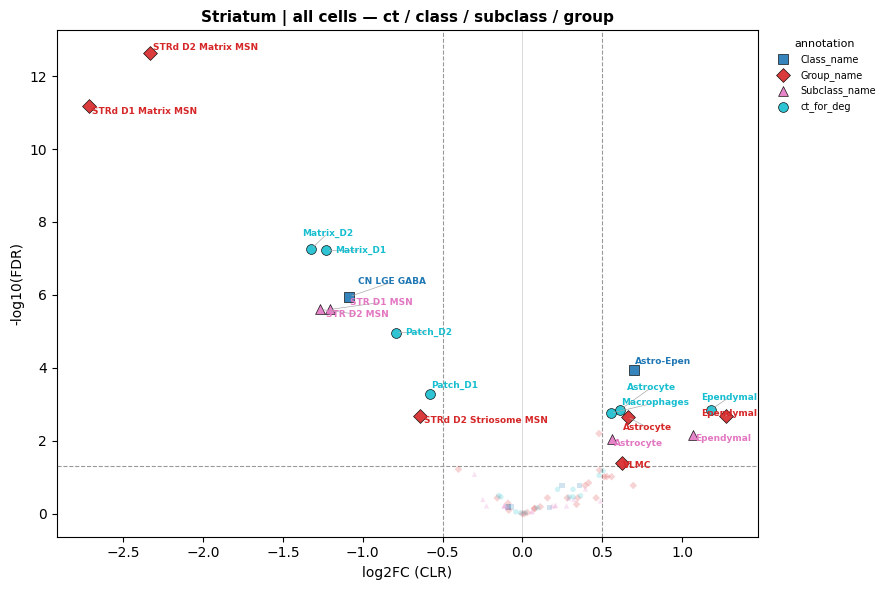

/tmp/ipykernel_720848/2263908423.py:17: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap   = plt.cm.get_cmap("tab10", len(groups))


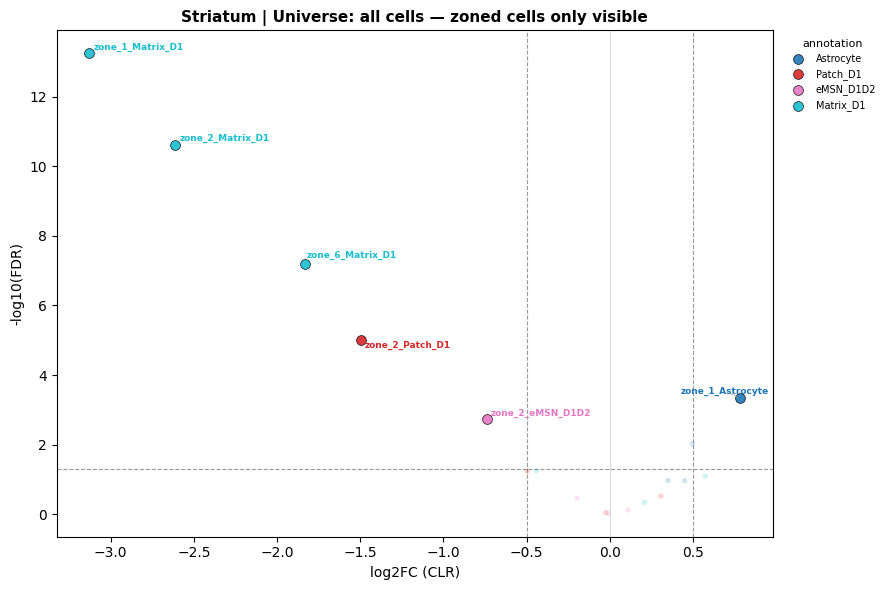

/tmp/ipykernel_720848/2263908423.py:17: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap   = plt.cm.get_cmap("tab10", len(groups))


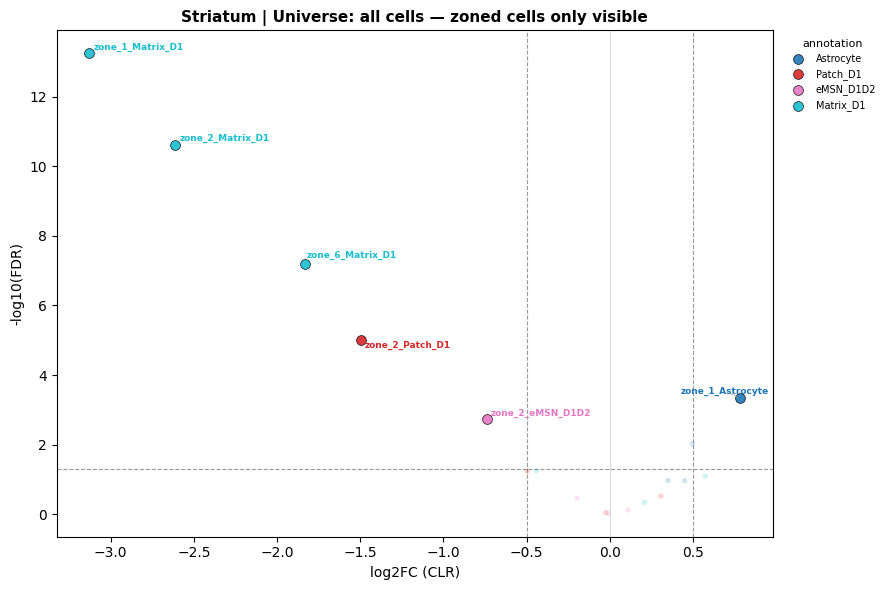

/tmp/ipykernel_720848/2263908423.py:17: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap   = plt.cm.get_cmap("tab10", len(groups))


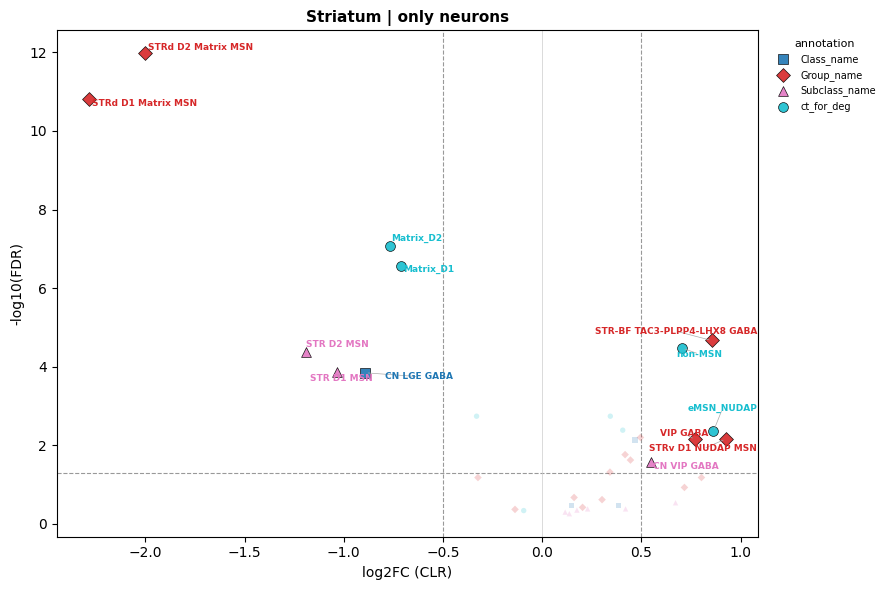

/tmp/ipykernel_720848/2263908423.py:17: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap   = plt.cm.get_cmap("tab10", len(groups))


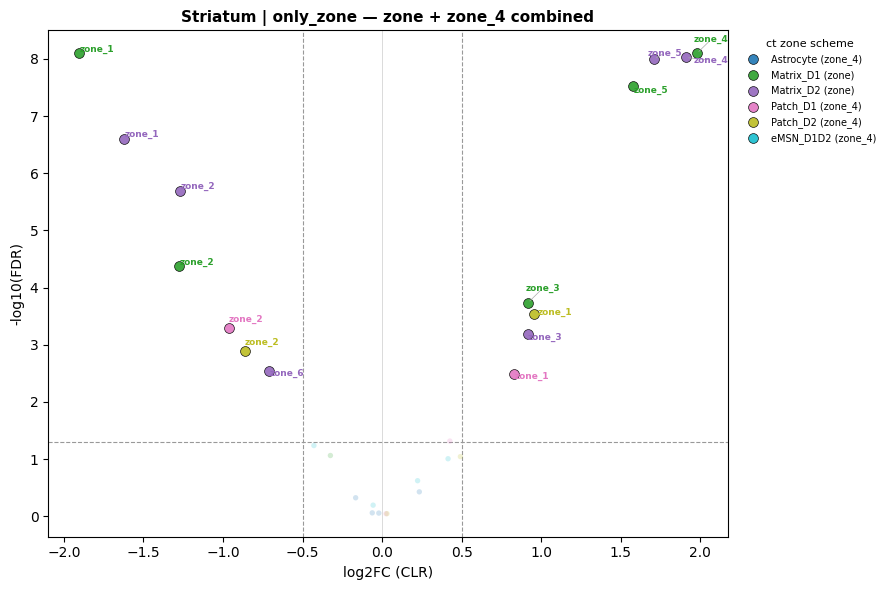

In [ ]:
from adjustText import adjust_text

BASE     = SAVE_FOLDER                          # fix 1: use variable, not hardcoded path
FDR_THR  = 0.05
LFC_THR  = 0.5
CONTRAST = CONTRAST_STIM                        # fix 2: use variable, not hardcoded "XDP"

MARKERS = {"ct_for_deg": "o", "Class_name": "s", "Subclass_name": "^", "Group_name": "D"}

def volcano(df, title, save_path, color_col="annotation", label_col="cell_type",
            fdr_thr=FDR_THR, lfc_thr=LFC_THR, figsize=(9, 6)):
    df = df[df["coefficient"].str.contains(CONTRAST, na=False)].copy()
    df["-logFDR"] = -np.log10(df["adj.P.Val"].clip(1e-15))
    df["sig"] = (df["adj.P.Val"] < fdr_thr) & (df["logFC"].abs() > lfc_thr)

    groups = sorted(df[color_col].unique())
    cmap   = plt.cm.get_cmap("tab10", len(groups))
    colors = {g: cmap(i) for i, g in enumerate(groups)}

    fig, ax = plt.subplots(figsize=figsize)
    ax.axhline(-np.log10(fdr_thr), color="#999", lw=0.8, ls="--", zorder=0)
    ax.axvline( lfc_thr, color="#999", lw=0.8, ls="--", zorder=0)
    ax.axvline(-lfc_thr, color="#999", lw=0.8, ls="--", zorder=0)
    ax.axvline(0, color="#ccc", lw=0.5, zorder=0)

    texts = []
    for g, grp in df.groupby(color_col):
        c  = colors[g]
        mk = MARKERS.get(g, "o")
        ax.scatter(grp.loc[~grp["sig"], "logFC"], grp.loc[~grp["sig"], "-logFDR"],
                   s=15, marker=mk, color=c, alpha=0.2, edgecolors="none", zorder=2)
        sig = grp[grp["sig"]]
        ax.scatter(sig["logFC"], sig["-logFDR"],
                   s=50, marker=mk, color=c, alpha=0.9,
                   edgecolors="black", linewidths=0.5, zorder=3,
                   label=g.replace("zone_4_by_","").replace("zone_by_",""))  # fix 3: new col names
        for _, r in sig.iterrows():
            texts.append(ax.text(r["logFC"], r["-logFDR"], r[label_col],
                                 fontsize=6.5, color=c, fontweight="bold", zorder=4))

    if texts:
        try:
            adjust_text(texts, ax=ax,
                        arrowprops=dict(arrowstyle="-", color="#aaa", lw=0.5),
                        expand_text=(1.1, 1.3), force_text=(0.4, 0.6))
        except Exception:
            pass

    ax.set_xlabel("log2FC (CLR)", fontsize=10)
    ax.set_ylabel("-log10(FDR)", fontsize=10)
    ax.set_title(title, fontsize=11, fontweight="bold")
    handles, labels = ax.get_legend_handles_labels()
    seen = dict(zip(labels, handles))
    ax.legend(seen.values(), seen.keys(), title=color_col.replace("_"," "),
              fontsize=7, title_fontsize=8,
              bbox_to_anchor=(1.01, 1), loc="upper left", frameon=False)
    plt.tight_layout()
    fig.savefig(save_path)
    plt.show()


df_all  = pd.read_csv(f"{BASE}/all_cells/merged_results.csv")
df_neu  = pd.read_csv(f"{BASE}/only_neurons/merged_results.csv")

NON_ZONE = ["ct_for_deg", "Class_name", "Subclass_name", "Group_name"]

# 1. all cells — ct / class / subclass / group
volcano(df_all[df_all["annotation"].isin(NON_ZONE)],
        title=f"{TISSUE} | all cells — ct / class / subclass / group",
        save_path=f"{BASE}/all_cells/volcano_ct.png")

# 2. all cells — zone_4_by_* + zone_by_* combined (zoned cells only)
_zone4 = df_all[df_all["annotation"].str.startswith("zone_4_by_")].copy()
_zone4 = _zone4[_zone4["cell_type"].str.match(r"^zone_\d+_")]

_zone = df_all[df_all["annotation"].str.startswith("zone_by_")].copy()
_zone = _zone[_zone["cell_type"].str.match(r"^zone_\d+_")]

_zones_combined = pd.concat([_zone4, _zone], ignore_index=True)
#_zones_combined = _zones_combined[~_zones_combined["annotation"].isin(["zone_by_Matrix_D2", "zone_4_by_Patch_D2"])]
if not _zones_combined.empty:
    volcano(_zones_combined, title=f"{TISSUE} | Universe: all cells — zoned cells only visible",
            save_path=f"{BASE}/all_cells/volcano_zones_combined.png")
    volcano(_zones_combined, title=f"{TISSUE} | Universe: all cells — zoned cells only visible",
            save_path=f"{BASE}/all_cells/volcano_zones_combined.pdf")


# 4. only neurons
volcano(df_neu, title=f"{TISSUE} | only neurons",
        save_path=f"{BASE}/only_neurons/volcano_only_neurons.png")

# 3. only_zone — zone + zone_4 combined (Striatum only)
_zone_path = f"{BASE}/only_zone/all_results.csv"
if os.path.exists(_zone_path):
    df_zone = pd.read_csv(_zone_path)
    df_zone["ct_zone_scheme"] = df_zone["ct_used_for_zoning"] + " (" + df_zone["zone_col"] + ")"
    volcano(df_zone,
            title=f"{TISSUE} | only_zone — zone + zone_4 combined",
            color_col="ct_zone_scheme",
            save_path=f"{BASE}/only_zone/volcano_zones_combined.png")
else:
    print(f"Skipping only_zone plots — no zone analysis found for {TISSUE}")


# ---

In [9]:
a = sc.read_h5ad("/home/gdallagl/myworkdir/XDP/data/STR_zonation_references_h5ad/Astrocyte_4_zones.h5ad", backed="r")

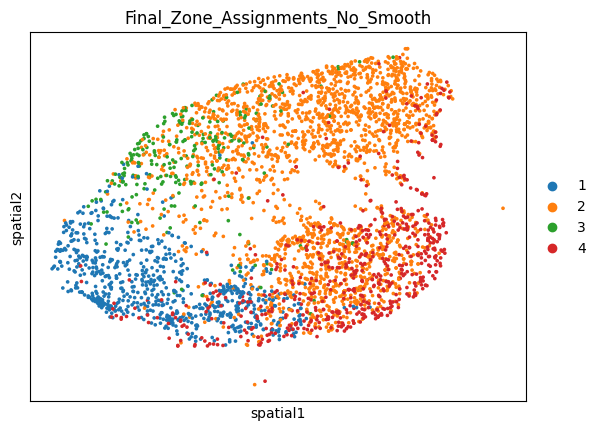

In [14]:
a.obsm["spatial"]  = a.obs[["x", "y"]].values
adata_sub = a[a.obs["donor_id"] == "PT13935"].to_memory().copy()
ZONE_LABELS_COL_NAME_IN_REF = "Final_Zone_Assignments_No_Smooth" #ATTENTION: must be the same of the mapping scirpt

sc.pl.embedding(adata_sub, basis="spatial", color=ZONE_LABELS_COL_NAME_IN_REF)

/tmp/ipykernel_1940157/4027475441.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(["zone_4", "donor_id"])


donor_id,PCMC-16-011,PCMC-16-012,SCF-18-003,SCF-18-004,SCF-18-006,SCF-19-009,SCF-19-014,SCF-19-018,SCF-19-020,SCF-20-023,...,SCF_22_067CM,SCF_23-080,SCF_23-081CM,SCF_23-083,SCF_23_070_MMC,SCF_23_072CF,SCF_23_074CF,SCF_23_075CM,SCF_23_079CF,unassigned
zone_4,,,,,,,,,,,,,,,,,,,,,
1,4,9,39,5,26,13,7,20,35,8,...,6,5,4,3,6,6,27,1,5,0
2,1,28,36,4,8,17,29,5,10,16,...,24,31,9,1,8,15,14,26,9,0
3,2,7,36,20,10,19,23,7,33,10,...,15,13,6,3,15,31,26,21,4,0
4,5,12,33,5,13,6,8,9,15,16,...,6,5,1,1,3,8,10,7,7,0


<Axes: xlabel='donor_id', ylabel='zone_4'>

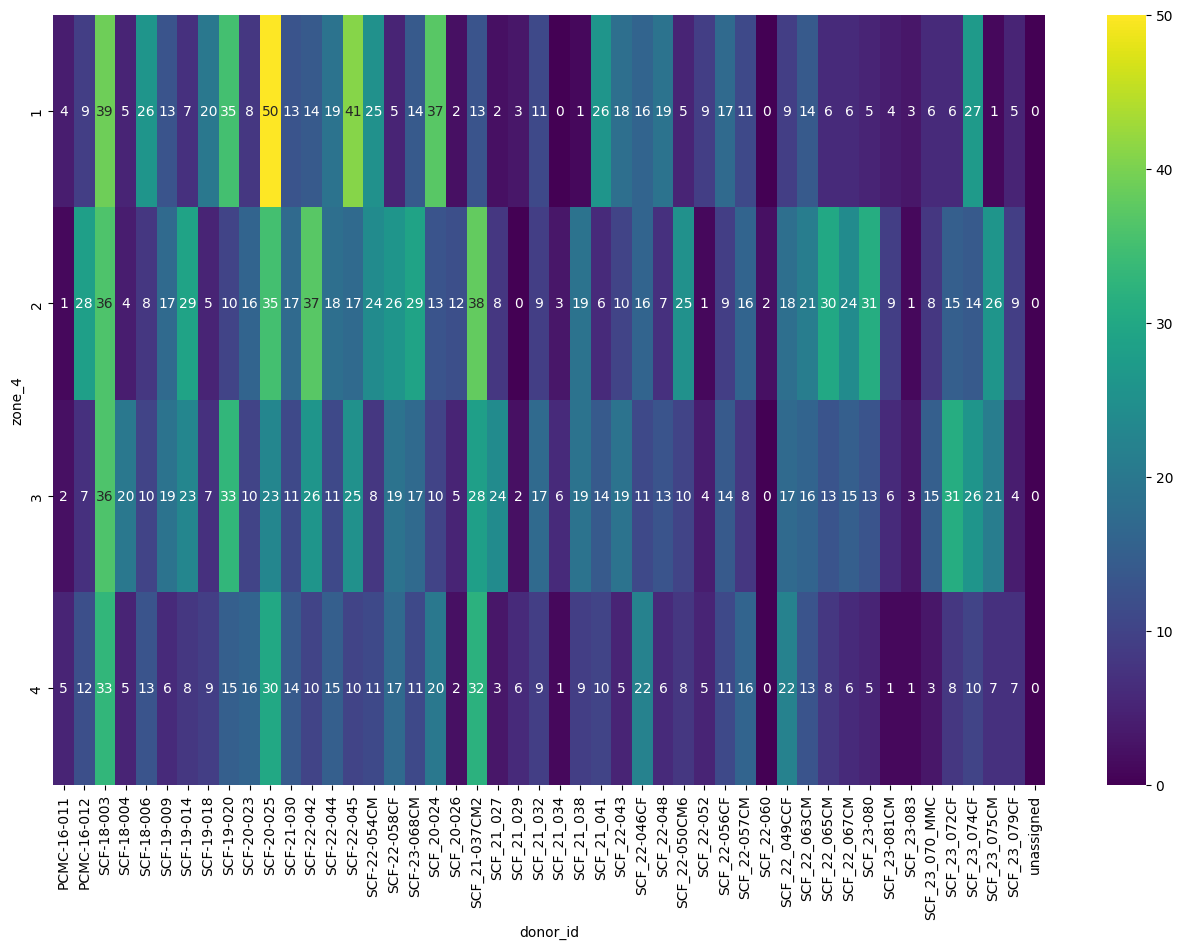

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create count matrix
counts = (
    adata.obs
    .query("ct_for_deg == 'eMSN_D1D2'")
    .groupby(["zone_4", "donor_id"])
    .size()
    .unstack(fill_value=0)
)
display(counts)

plt.figure(figsize=(16, 10))

sns.heatmap(
    counts,
    annot=True,
    fmt="d",
    cmap="viridis"
)